<a href="https://colab.research.google.com/github/MdShajalalsojib/Data-Mining-Lab/blob/main/Lab_Report_002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

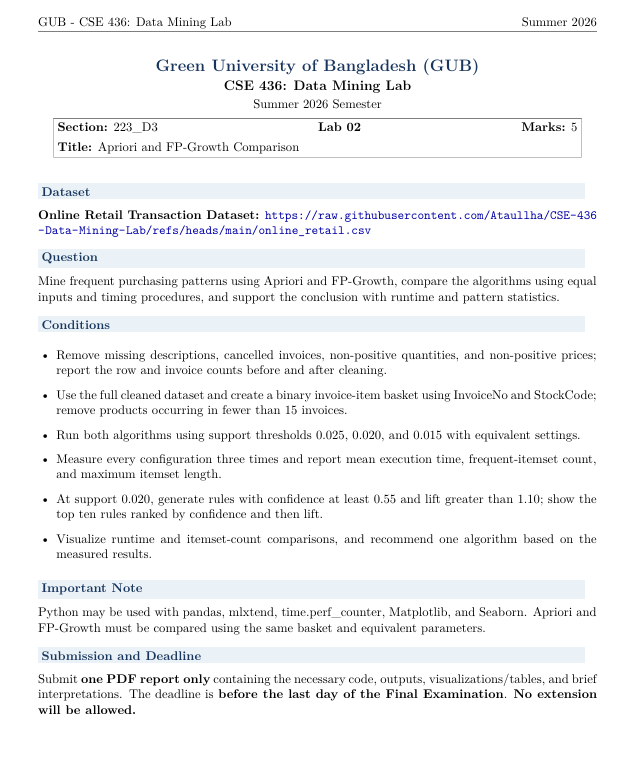

# **Libraries**

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from time import perf_counter
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules


# **Load Dataset**

In [44]:
URL = "https://raw.githubusercontent.com/Ataullha/CSE-436-Data-Mining-Lab/refs/heads/main/online_retail.csv"

df = pd.read_csv(URL, encoding="ISO-8859-1")

rows_before = len(df)
invoices_before = df["InvoiceNo"].nunique()

# **Data Cleaning Result**

In [48]:
df = df.dropna(subset=["Description"])

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df = df.reset_index(drop=True)

rows_after = len(df)
invoices_after = df["InvoiceNo"].nunique()

print("=" * 70)
print("DATA CLEANING RESULT")
print("=" * 70)

print(f"Rows before cleaning       : {rows_before:,}")
print(f"Rows after cleaning        : {rows_after:,}")
print(f"Rows removed               : {rows_before - rows_after:,}")

print(f"Invoices before cleaning   : {invoices_before:,}")
print(f"Invoices after cleaning    : {invoices_after:,}")
print(f"Invoices removed           : {invoices_before - invoices_after:,}")


DATA CLEANING RESULT
Rows before cleaning       : 99,999
Rows after cleaning        : 97,647
Rows removed               : 2,352
Invoices before cleaning   : 4,656
Invoices after cleaning    : 3,527
Invoices removed           : 1,129


# **Remove Products Occurring in Fewer Than 15 Invoices**

In [49]:
product_frequency = (
    df.groupby("StockCode")["InvoiceNo"]
    .nunique()
)

valid_products = product_frequency[
    product_frequency >= 15
].index

df = df[df["StockCode"].isin(valid_products)]


# **Binary Basket Information**

In [50]:
basket = (
    df.groupby(["InvoiceNo", "StockCode"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

basket = (basket > 0).astype(int)

print("\n" + "=" * 70)
print("BINARY BASKET INFORMATION")
print("=" * 70)

print(f"Number of invoices : {basket.shape[0]:,}")
print(f"Number of products : {basket.shape[1]:,}")
print(f"Basket size        : {basket.shape}")


BINARY BASKET INFORMATION
Number of invoices : 3,469
Number of products : 1,665
Basket size        : (3469, 1665)


# **Function for Apriori and FP-Growth**

In [51]:
def run_algorithm(algorithm, support):

    times = []
    itemsets = None

    for _ in range(3):

        start = perf_counter()

        if algorithm == "Apriori":
            itemsets = apriori(
                basket,
                min_support=support,
                use_colnames=True
            )

        elif algorithm == "FP-Growth":
            itemsets = fpgrowth(
                basket,
                min_support=support,
                use_colnames=True
            )

        end = perf_counter()

        times.append(end - start)

    mean_time = np.mean(times)

    if len(itemsets) > 0:
        max_length = itemsets["itemsets"].apply(len).max()
    else:
        max_length = 0

    return mean_time, len(itemsets), max_length, itemsets

# **Apriori and FP-Growth Comparison**


In [53]:
supports = [0.025, 0.020, 0.015]

results = []

itemsets_020 = {}

for support in supports:

    # -------------------------
    # Apriori
    # -------------------------

    apriori_time, apriori_count, apriori_max, apriori_sets = \
        run_algorithm("Apriori", support)

    results.append([
        "Apriori",
        support,
        apriori_time,
        apriori_count,
        apriori_max
    ])

# **FP-Growth**

In [54]:

    fp_time, fp_count, fp_max, fp_sets = \
        run_algorithm("FP-Growth", support)

    results.append([
        "FP-Growth",
        support,
        fp_time,
        fp_count,
        fp_max
    ])

    # Store FP-Growth itemsets at support 0.020
    if support == 0.020:
        itemsets_020 = fp_sets


# **Apriori and FP-Growth Comparison Table**

In [55]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Support",
        "Mean Runtime (seconds)",
        "Frequent Itemsets",
        "Maximum Itemset Length"
    ]
)

print("\n" + "=" * 70)
print("APRIORI AND FP-GROWTH COMPARISON")
print("=" * 70)

print(comparison.to_string(index=False))


APRIORI AND FP-GROWTH COMPARISON
Algorithm  Support  Mean Runtime (seconds)  Frequent Itemsets  Maximum Itemset Length
  Apriori    0.025                3.059978                298                       2
  Apriori    0.020                7.136103                517                       3
  Apriori    0.015               19.063649               1099                       3
FP-Growth    0.015                8.138534               1099                       3


# **Runtime Comparison**

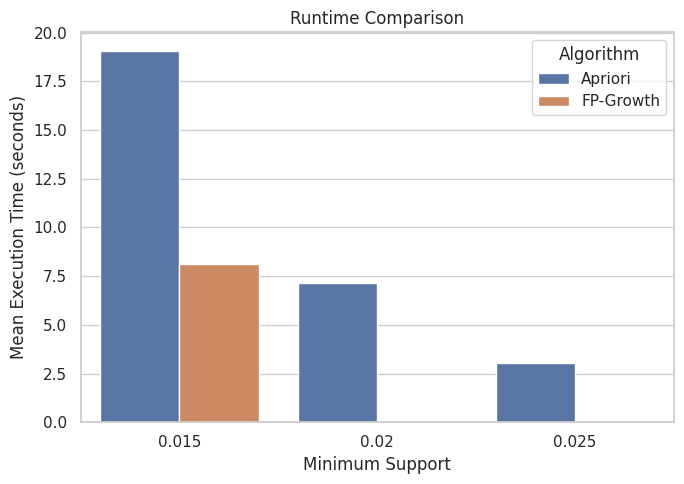

In [62]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=comparison,
    x="Support",
    y="Mean Runtime (seconds)",
    hue="Algorithm"
)

plt.title("Runtime Comparison")
plt.xlabel("Minimum Support")
plt.ylabel("Mean Execution Time (seconds)")
plt.tight_layout()
plt.show()

# **Frequent Itemset Count Comparison**

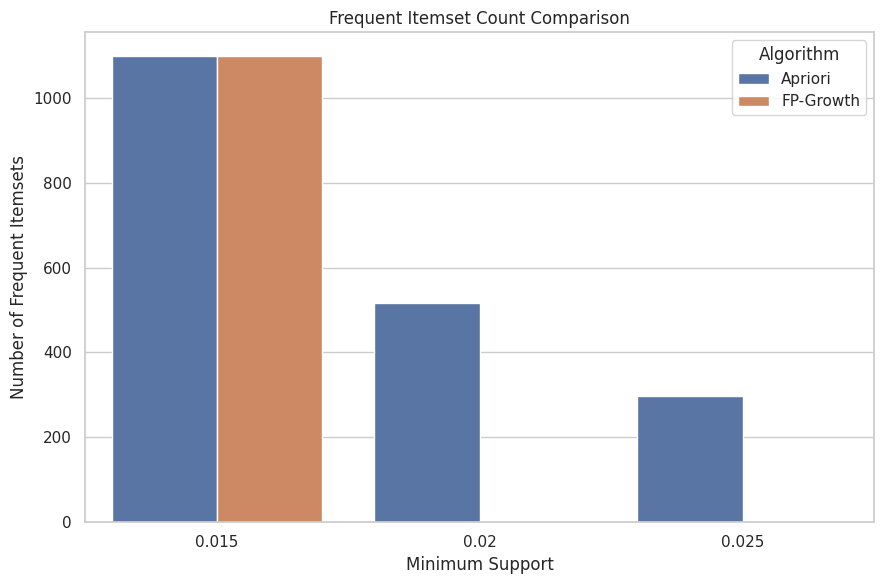

In [57]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=comparison,
    x="Support",
    y="Frequent Itemsets",
    hue="Algorithm"
)

plt.title("Frequent Itemset Count Comparison")
plt.xlabel("Minimum Support")
plt.ylabel("Number of Frequent Itemsets")
plt.tight_layout()
plt.show()

# **Maximum Itemset Length Comparison**

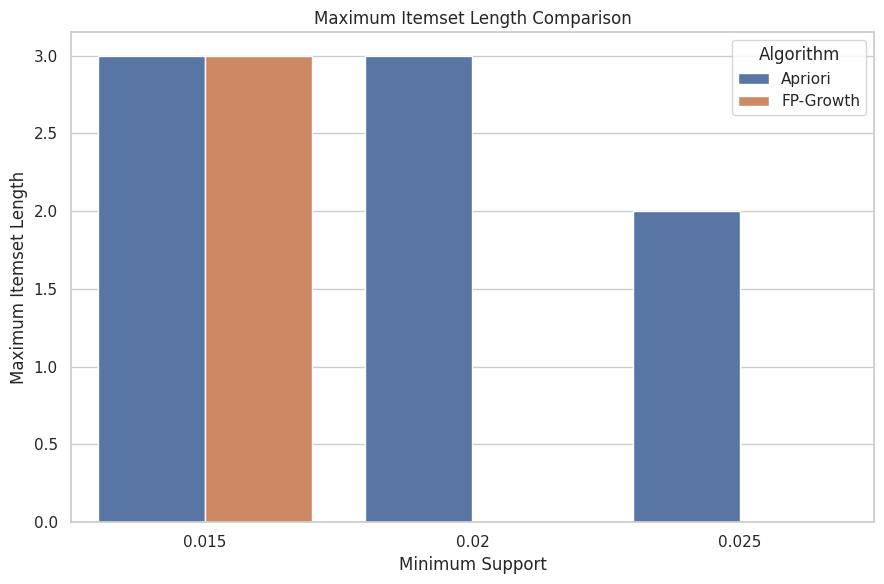

In [58]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=comparison,
    x="Support",
    y="Maximum Itemset Length",
    hue="Algorithm"
)

plt.title("Maximum Itemset Length Comparison")
plt.xlabel("Minimum Support")
plt.ylabel("Maximum Itemset Length")
plt.tight_layout()
plt.show()

#**10 Association Rules Lift**

In [61]:
# Generate frequent itemsets at support 0.020
itemsets_020 = fpgrowth(
    basket,
    min_support=0.020,
    use_colnames=True
)

# Generate association rules
rules = association_rules(
    itemsets_020,
    metric="confidence",
    min_threshold=0.55
)

# Apply lift condition
rules = rules[rules["lift"] > 1.10]

# Rank by confidence first, then lift
rules = rules.sort_values(
    by=["confidence", "lift"],
    ascending=[False, False]
)

# Select top 10 rules
top_10 = rules.head(10).copy()


# ============================================================
# Display Top 10 Rules
# ============================================================

print("=" * 80)
print("TOP 10 ASSOCIATION RULES")
print("=" * 80)

if len(top_10) > 0:

    top_10["Antecedents"] = top_10["antecedents"].apply(
        lambda x: ", ".join(sorted(map(str, x)))
    )

    top_10["Consequents"] = top_10["consequents"].apply(
        lambda x: ", ".join(sorted(map(str, x)))
    )

    output_rules = top_10[
        [
            "Antecedents",
            "Consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].copy()

    output_rules.columns = [
        "Antecedents",
        "Consequents",
        "Support",
        "Confidence",
        "Lift"
    ]

    output_rules["Support"] = output_rules["Support"].round(4)
    output_rules["Confidence"] = output_rules["Confidence"].round(4)
    output_rules["Lift"] = output_rules["Lift"].round(4)

    print(output_rules.to_string(index=False))

else:
    print("No rules satisfy Confidence >= 0.55 and Lift > 1.10.")

TOP 10 ASSOCIATION RULES
 Antecedents Consequents  Support  Confidence    Lift
       22963       22962   0.0219      0.8352 27.3320
       22198       22197   0.0202      0.8140 10.9868
22423, 22699       22697   0.0205      0.8068 14.8875
       22745       22748   0.0231      0.7619 23.3898
  22197, DOT      85099B   0.0208      0.7500  7.6748
       22729       22726   0.0225      0.7429 12.6944
       22697       22699   0.0395      0.7287 13.3050
      84997C      84997D   0.0208      0.7273 21.9383
22423, 22697       22699   0.0205      0.7245 13.2277
       22699       22697   0.0395      0.7211 13.3050
